In [36]:
import numpy as np 
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("train.csv")
df = df.drop(columns=["id", "date"])

df = df.drop(columns=[f"temp_{5}", f"wind_{5}", f"temp_night_{5}", f"wind_night_{5}", f"temp_night_{5}", f"ssrd_ratio_{5}"])

train_df, test_df = train_test_split(df, test_size=0.5, random_state=42)

# terms = []
# for col in df.columns:
#     if col == "demand":
#         continue
#     if col.startswith(("temp", "temp_night")):
#         terms.append(col)
#         terms.append(f"I({col}**3)")
#     else:
#         terms.append(col)

# model_str = "demand ~ " + " + ".join(terms)

# model = smf.ols(model_str, data=df).fit()
# print(model.summary())

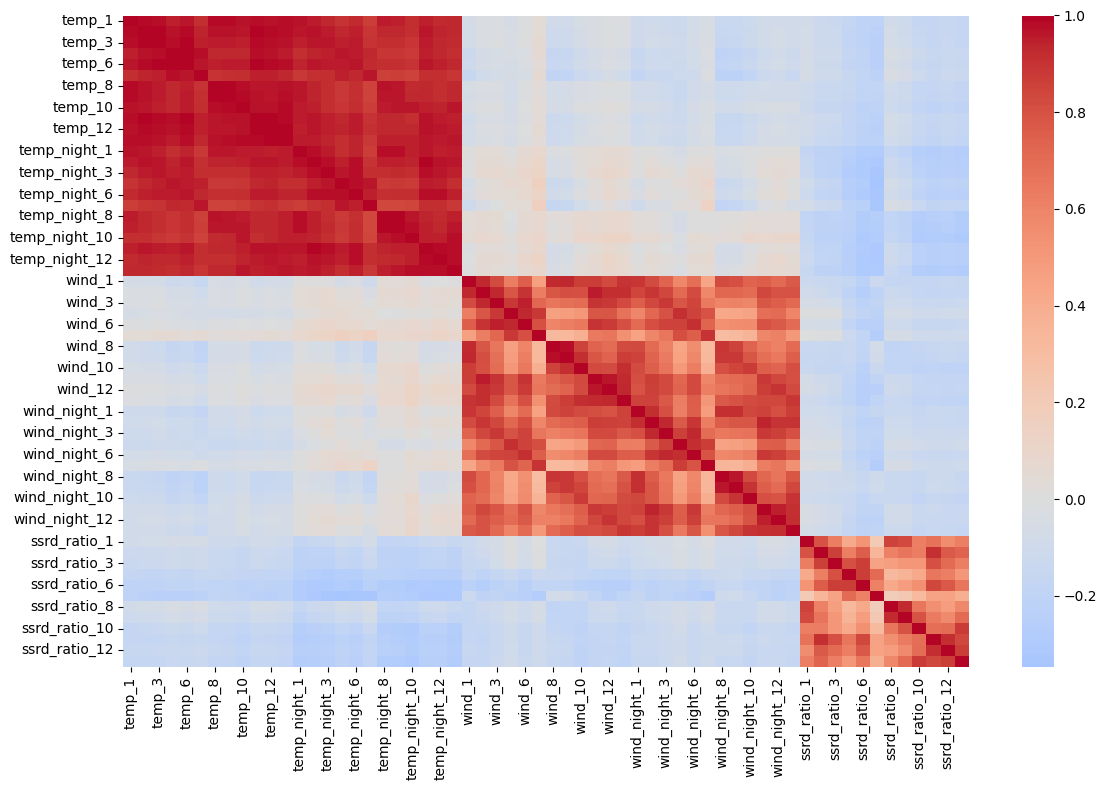

In [34]:
df_wo_y = df.drop(columns="demand")
# corr_wo_y = df_wo_y.corr()

# print(corr_wo_y.columns.tolist())

# # Plot heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(corr_wo_y, cmap="coolwarm", center=0)
# plt.xticks(rotation=45, ha="right")  # rotate x labels
# plt.yticks(rotation=0)               # keep y labels horizontal
# plt.tight_layout()
# plt.show()
import re

def get_num(col):
    return int(re.search(r'\d+', col).group())

temp_cols       = sorted([col for col in df.columns if col.startswith("temp_") and not col.startswith("temp_night_")], key=get_num)
temp_night_cols = sorted([col for col in df.columns if col.startswith("temp_night_")], key=get_num)
wind_cols       = sorted([col for col in df.columns if col.startswith("wind_") and not col.startswith("wind_night_")], key=get_num)
wind_night_cols = sorted([col for col in df.columns if col.startswith("wind_night_")], key=get_num)
ssrd_cols       = sorted([col for col in df.columns if col.startswith("ssrd_")], key=get_num)

ordered_cols = temp_cols + temp_night_cols + wind_cols + wind_night_cols + ssrd_cols

corr = df_wo_y[ordered_cols].corr()

# print(corr.shape)
# print(len(ordered_cols))
# print(ordered_cols)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0)
# plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

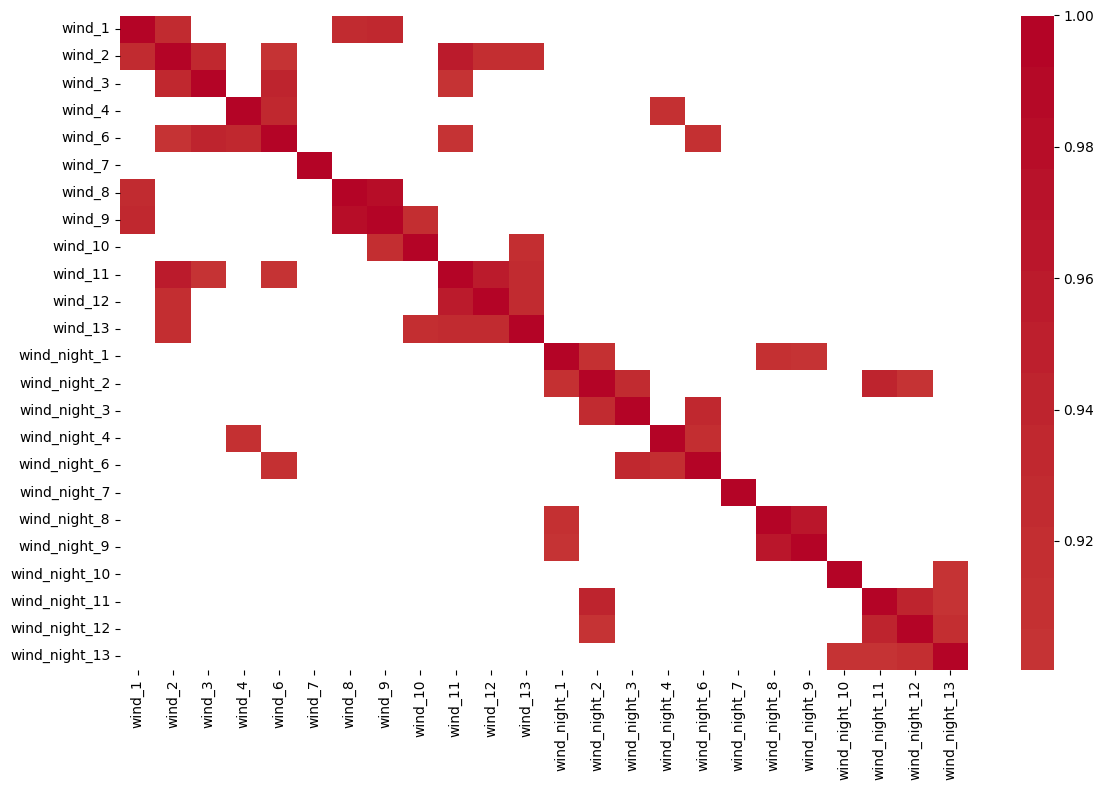

In [45]:
corr_wind = df_wo_y[wind_cols + wind_night_cols].corr()
mask = np.abs(corr_wind) < 0.9

plt.figure(figsize=(12, 8))
sns.heatmap(corr_wind, mask=mask, cmap="coolwarm", center=0, linewidths=0)
# plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

2, 13, 11 and 6 are problems in wind

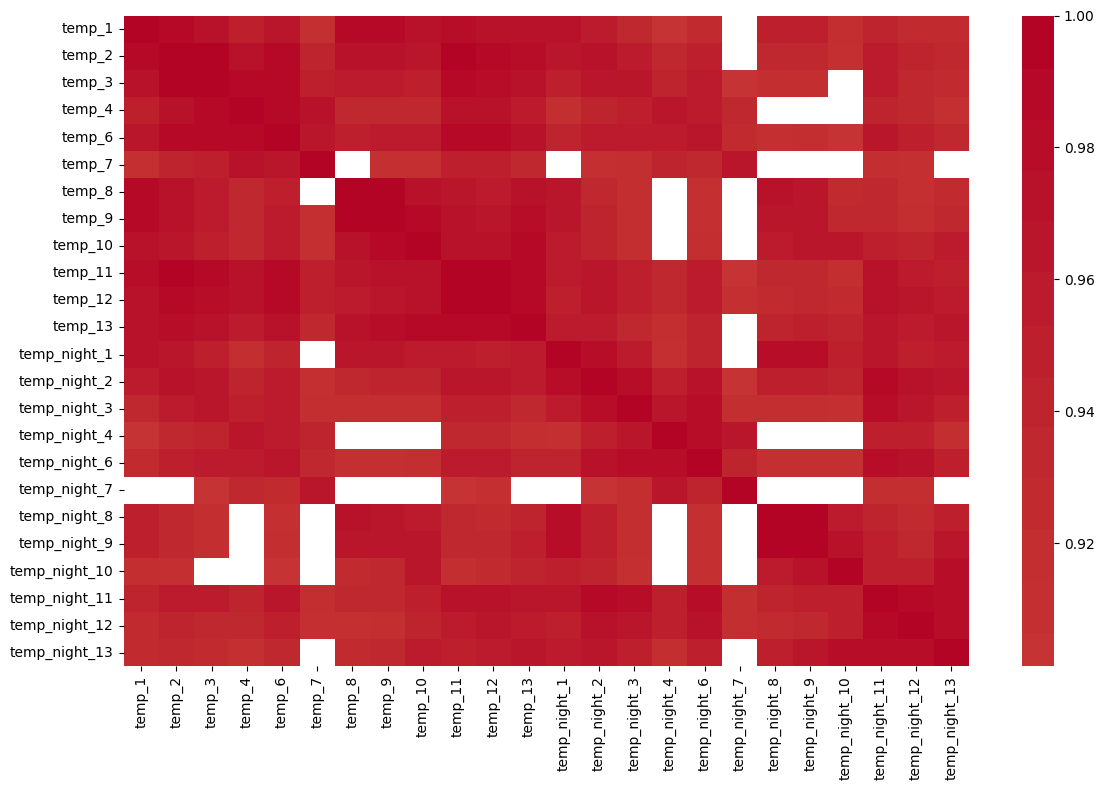

In [48]:
corr_temp = df_wo_y[temp_cols + temp_night_cols].corr()
mask = np.abs(corr_temp) < 0.9

plt.figure(figsize=(12, 8))
sns.heatmap(corr_temp, mask=mask, cmap="coolwarm", center=0, linewidths=0)
# plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

6, 11, 12, 1, 2, 3 (in both regular and night) are a big problem in temperature

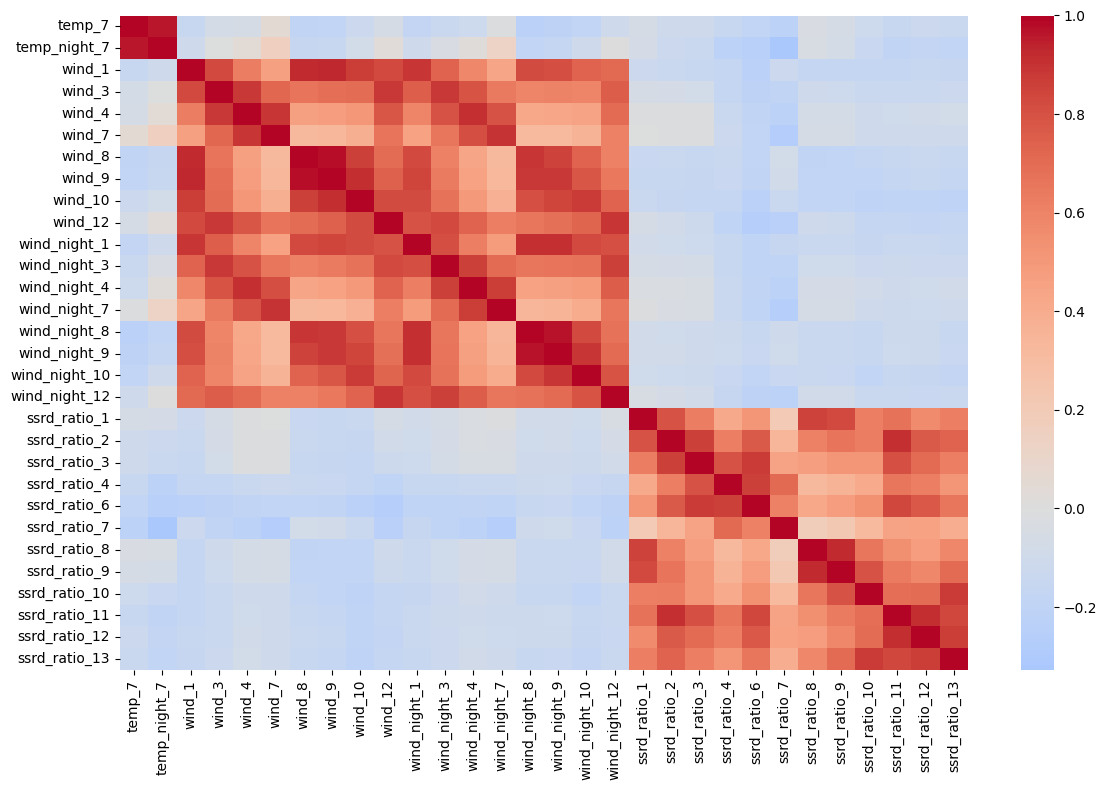

In [57]:
wind_drop = [2, 6, 11, 13]
temp_drop = [i for i in range(1, 14) if i != 7 and i != 5]
drop = [f"wind_{w}" for w in wind_drop] + [f"wind_night_{w}" for w in wind_drop] + [f"temp_{t}" for t in temp_drop] + [f"temp_night_{t}" for t in temp_drop]
df_new = df_wo_y.drop(columns=drop)


temp_cols       = sorted([col for col in df_new.columns if col.startswith("temp_") and not col.startswith("temp_night_")], key=get_num)
temp_night_cols = sorted([col for col in df_new.columns if col.startswith("temp_night_")], key=get_num)
wind_cols       = sorted([col for col in df_new.columns if col.startswith("wind_") and not col.startswith("wind_night_")], key=get_num)
wind_night_cols = sorted([col for col in df_new.columns if col.startswith("wind_night_")], key=get_num)
ssrd_cols       = sorted([col for col in df_new.columns if col.startswith("ssrd_")], key=get_num)

ordered_cols = temp_cols + temp_night_cols + wind_cols + wind_night_cols + ssrd_cols

corr = df_new[ordered_cols].corr()

# print(corr.shape)
# print(len(ordered_cols))
# print(ordered_cols)

# mask = np.abs(corr) < 0.9
mask = None

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, linewidths=0)
# plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# corr_new = df_new.corr()
# plt.figure(figsize=(12, 8))
# sns.heatmap(corr_new, cmap="coolwarm", center=0, linewidths=0)
# # plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()

In [13]:
def forward_stepwise_regression(df, target, candidate_columns):
    selected = []
    remaining = set(candidate_columns)
    best_score = float("inf")
    
    while remaining:
        scores = {}
        for col in remaining:
            cols = selected + [col]
            formula = f"{target} ~ {' + '.join(cols)}"
            score = smf.ols(formula=formula, data=df).fit().aic
            scores[col] = score
        
        best_col = min(scores, key=scores.get)
        if scores[best_col] < best_score:
            best_score = scores[best_col]
            selected.append(best_col)
            remaining.remove(best_col)
        else:
            break
    
    return selected

# candidate_cols = [col for col in train_df.columns if col != "demand"]
candidate_cols = []
for col in train_df.columns:
    if col == "demand":
        continue
    candidate_cols.append(col)
    if col.startswith(("temp", "temp_night")):
        candidate_cols.append(f"I({col}**3)")

df_scaled_train = (train_df - train_df.mean()) / train_df.std()

# print(train_df.mean())
    
selected_cols = forward_stepwise_regression(train_df, "demand", candidate_cols)

df_scaled = (test_df - test_df.mean()) / test_df.std()

# Fit final model
# final_model = smf.ols(f"demand ~ {' + '.join(selected_cols)}", data=df_scaled).fit_regularized(method="elastic_net", alpha=0.01, L1_wt=0)
final_model = smf.ols(f"demand ~ {' + '.join(selected_cols)}", data=test_df).fit()
# print(final_model.summary())

In [14]:
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     1249.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:06:38   Log-Likelihood:                -6520.1
No. Observations:                1644   AIC:                         1.311e+04
Df Residuals:                    1610   BIC:                         1.329e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              269.3164 

In [15]:
residuals = final_model.resid
# residuals = test_df["demand"] - final_model.predict(test_df)
# residuals = df_scaled["demand"] - final_model.predict(df_scaled)


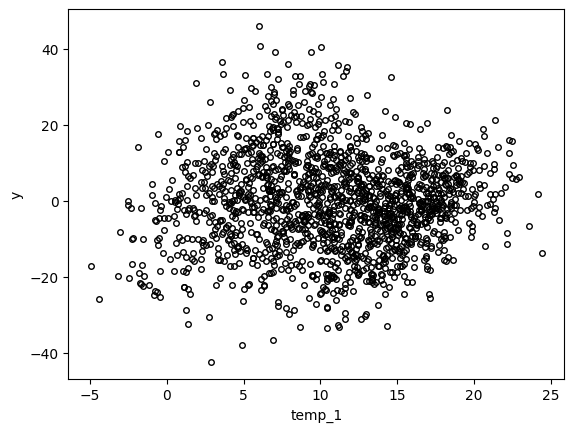

In [19]:
smooth = lowess(residuals, test_df["temp_1"], frac=0.3) 

plt.plot(test_df["temp_1"], residuals, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("temp_1")
plt.ylabel("y")
plt.show()

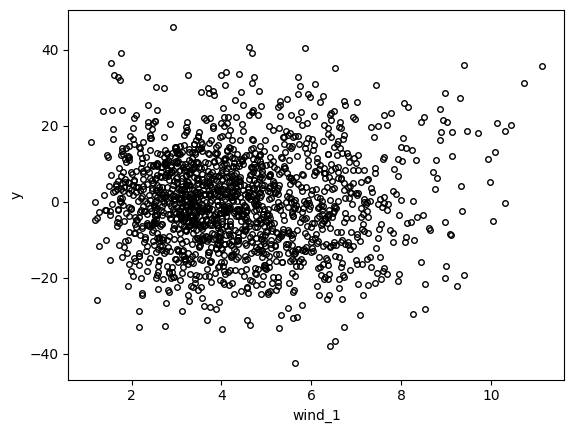

In [17]:
smooth = lowess(residuals, test_df["wind_1"], frac=0.3) 

plt.plot(test_df["wind_1"], residuals, 'o', markersize=4, fillstyle='none', color='black')
# plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)
plt.xlabel("wind_1")
plt.ylabel("y")
plt.show()